# Automating Flower Classification Using Deep Learning

**Business Context:** A startup wants an automated flower classification system that identifies 102 species from images. Use cases include mobile plant ID apps, e-commerce cataloging, and personalized recommendations.

**Dataset:** Oxford Flowers 102 (via TensorFlow Datasets)
- 102 flower species, varying lighting/backgrounds
- Train: 1,020 images (10/class) | Val: 1,020 (10/class) | Test: 6,149 (40-258/class)

**Approach:** Transfer learning with EfficientNet, progressive fine-tuning

---

## Phase 1: EDA & Data Understanding

In [3]:
# Cell 1: Environment Setup & Imports

# Colab compatibility: install dependencies if running in Colab
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q tensorflow tensorflow-datasets scikit-learn

import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# GPU check
print(f"TensorFlow version: {tf.__version__}")
print(f"Running in Colab: {IN_COLAB}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU available: {gpus[0].name}")
    # Limit VRAM growth to avoid OOM on 4GB card
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU detected — training will be slow")

print(f"NumPy: {np.__version__}")
print("Setup complete.")

TensorFlow version: 2.21.0
Running in Colab: False
No GPU detected — training will be slow
NumPy: 2.2.6
Setup complete.


In [ ]:
# Cell 2: Load Dataset & Inspect Splits

# Load Oxford Flowers 102 with metadata
(train_set, val_set, test_set), info = tfds.load(
    'oxford_flowers102',
    split=['train', 'validation', 'test'],
    with_info=True,
    as_supervised=True
)

# Dataset overview
print(info.description[:200])
print(f"\nNumber of classes: {info.features['label'].num_classes}")
print(f"\nSplit sizes:")
for split_name, split_info in info.splits.items():
    print(f"  {split_name}: {split_info.num_examples} images")

print(f"\nImage shape: {info.features['image'].shape}")
print(f"Label type: {info.features['label'].dtype}")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /home/berto/tensorflow_datasets/oxford_flowers102/incomplete.K7X5OH_2.1.1/oxford_flowers102-test.tfr…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /home/berto/tensorflow_datasets/oxford_flowers102/incomplete.K7X5OH_2.1.1/oxford_flowers102-validati…

Dataset oxford_flowers102 downloaded and prepared to /home/berto/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.
The Oxford Flowers 102 dataset is a consistent of 102 flower categories commonly
occurring in the United Kingdom. Each class consists of between 40 and 258
images. The images have large scale, pose an

Number of classes: 102

Split sizes:
  train: 1020 images
  test: 6149 images
  validation: 1020 images

Image shape: (None, None, 3)
Label type: <dtype: 'int64'>


I0000 00:00:1775174442.462201  149965 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Train: {10} per class (uniform)
Val: {10} per class (uniform)
Test: min=20, max=238, mean=60.3


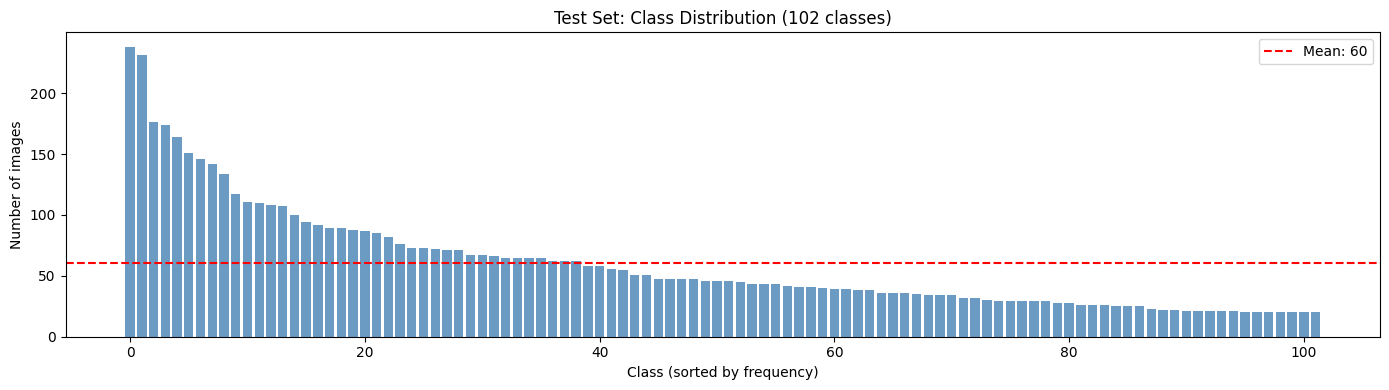

In [5]:
# Cell 3: Class Distribution Across Splits

# Count labels per class for each split
def count_labels(dataset):
    labels = [label.numpy() for _, label in dataset]
    return Counter(labels)

train_counts = count_labels(train_set)
val_counts = count_labels(val_set)
test_counts = count_labels(test_set)

# Summary stats
print("Train: {} per class (uniform)".format(
    set(train_counts.values()) if len(set(train_counts.values())) <= 3
    else f"min={min(train_counts.values())}, max={max(train_counts.values())}"
))
print("Val: {} per class (uniform)".format(
    set(val_counts.values()) if len(set(val_counts.values())) <= 3
    else f"min={min(val_counts.values())}, max={max(val_counts.values())}"
))
print(f"Test: min={min(test_counts.values())}, max={max(test_counts.values())}, "
      f"mean={np.mean(list(test_counts.values())):.1f}")

# Plot test set distribution (train/val are uniform, test has the imbalance)
fig, ax = plt.subplots(figsize=(14, 4))
sorted_counts = sorted(test_counts.items(), key=lambda x: x[1], reverse=True)
classes, counts = zip(*sorted_counts)
ax.bar(range(len(classes)), counts, color='steelblue', alpha=0.8)
ax.set_xlabel('Class (sorted by frequency)')
ax.set_ylabel('Number of images')
ax.set_title('Test Set: Class Distribution (102 classes)')
ax.axhline(y=np.mean(counts), color='red', linestyle='--', label=f'Mean: {np.mean(counts):.0f}')
ax.legend()
plt.tight_layout()
plt.show()
